In [1]:
import os
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')


In [2]:
import os
print("LD_LIBRARY_PATH:", os.environ.get('LD_LIBRARY_PATH'))


LD_LIBRARY_PATH: /usr/local/cuda/lib64:


In [3]:
import tensorflow as tf
print("GPUs detected:", tf.config.list_physical_devices('GPU'))


2025-06-23 01:20:38.246251: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-23 01:20:38.256674: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750659638.269108   82709 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750659638.272499   82709 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750659638.281865   82709 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Cargar las imágenes y máscaras
def load_images_and_masks(image_dir, mask_dir, image_size=(224, 224)):
    images = []
    masks = []
    
    image_files = sorted(os.listdir(image_dir))  # Aseguramos que estén ordenados
    mask_files = sorted(os.listdir(mask_dir))   # Aseguramos que estén ordenados
    
    # Verificar que el número de archivos de imágenes y máscaras sea el mismo
    if len(image_files) != len(mask_files):
        print("Error: El número de imágenes no coincide con el número de máscaras.")
        return None, None

    for image_file, mask_file in zip(image_files, mask_files):
        # Asegurarse de que el nombre de la imagen y la máscara coincidan
        if image_file.split('.')[0] != mask_file.split('.')[0]:
            print(f"Error de coincidencia: {image_file} y {mask_file}")
            continue

        # Cargar imagen
        image_path = os.path.join(image_dir, image_file)
        mask_path = os.path.join(mask_dir, mask_file)
        
        # Leer y redimensionar imagen
        image = load_img(image_path, target_size=image_size)
        image = img_to_array(image) / 255.0  # Normalizar a [0,1]
        
        # Leer y redimensionar máscara
        mask = load_img(mask_path, target_size=image_size, color_mode='grayscale')
        mask = img_to_array(mask) / 255.0  # Normalizar a [0,1]
        
        images.append(image)
        masks.append(mask)
    
    return np.array(images), np.array(masks)

# Directorios con las imágenes y las máscaras
image_dir = 'dataset/aug_data/images'  # Reemplaza con la ruta de tus imágenes
mask_dir = 'dataset/aug_data/masks'    # Reemplaza con la ruta de tus máscaras

# Cargar el dataset
images, masks = load_images_and_masks(image_dir, mask_dir)
print(images.shape, masks.shape)  # Verifica que se hayan cargado correctamente


(2940, 224, 224, 3) (2940, 224, 224, 1)


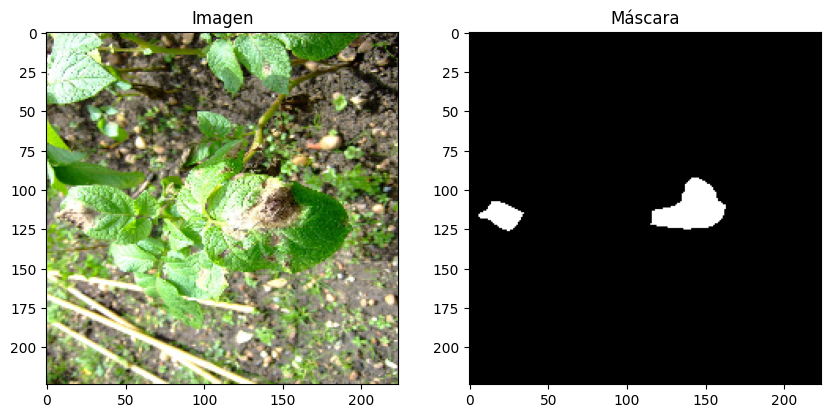

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Seleccionar un índice aleatorio
random_index = np.random.choice(len(images))

# Visualizar la imagen y su máscara correspondiente
plt.figure(figsize=(10, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(images[random_index])  # Usar random_index para la imagen seleccionada
plt.title('Imagen')

# Máscara correspondiente
plt.subplot(1, 2, 2)
plt.imshow(masks[random_index], cmap='gray')  # Usar random_index para la máscara seleccionada
plt.title('Máscara')

plt.show()


In [5]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam


def dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Cálculo de la función de pérdida Dice.
    :param y_true: Las etiquetas verdaderas (máscara).
    :param y_pred: Las predicciones del modelo.
    :param smooth: Un valor pequeño para evitar la división por cero.
    :return: Dice loss
    """
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    
    dice = (2. * intersection + smooth) / (union + smooth)
    
    return 1 - dice


def dice_coefficient(y_true, y_pred, smooth=1e-6):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

def iou(y_true, y_pred, smooth=1e-6):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    
    return intersection / (union + smooth)


def unet_model(input_size=(224, 224, 3)):
    inputs = layers.Input(input_size)

    # Contracción (Encoder)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    c1 = layers.Dropout(0.3)(c1) 
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    c2 = layers.Dropout(0.2)(c2) 
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    c4 = layers.Dropout(0.3)(c4) 
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Expansión (Decoder)
    u6 = layers.UpSampling2D((2, 2))(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.UpSampling2D((2, 2))(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.UpSampling2D((2, 2))(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.UpSampling2D((2, 2))(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = models.Model(inputs, outputs)

    # Especificar un learning rate
    learning_rate = 1e-3  # Ejemplo de learning rate bajo

    # Crear el optimizador Adam con un learning rate personalizado
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss=dice_loss, metrics=[dice_coefficient, iou])

    return model

# Crear el modelo
model = unet_model()



I0000 00:00:1750659703.691682   82709 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5578 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [9]:
# Dividir el dataset en entrenamiento y validación
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.2, random_state=42)

# Entrenar el modelo
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=6)


Epoch 1/10


I0000 00:00:1750659755.420619   82936 service.cc:152] XLA service 0x781098001df0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750659755.420695   82936 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-06-23 01:22:35.509115: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1750659756.208527   82936 cuda_dnn.cc:529] Loaded cuDNN version 91001
2025-06-23 01:22:41.370558: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.49GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-06-23 01:22:42.023736: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_b

392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - dice_coefficient: 0.0443 - iou: 0.0227 - loss: 0.9557

2025-06-23 01:24:23.701674: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.22GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-06-23 01:24:24.277102: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.14GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-06-23 01:24:24.661912: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.13GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-06-23 01:24:25.007373: W external/local_xla/xla/ts

392/392 ━━━━━━━━━━━━━━━━━━━━ 124s 235ms/step - dice_coefficient: 0.0443 - iou: 0.0227 - loss: 0.9557 - val_dice_coefficient: 0.0472 - val_iou: 0.0243 - val_loss: 0.9528
Epoch 2/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 85s 218ms/step - dice_coefficient: 0.0445 - iou: 0.0228 - loss: 0.9555 - val_dice_coefficient: 0.0472 - val_iou: 0.0243 - val_loss: 0.9528
Epoch 3/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 86s 220ms/step - dice_coefficient: 0.0474 - iou: 0.0244 - loss: 0.9526 - val_dice_coefficient: 0.0472 - val_iou: 0.0243 - val_loss: 0.9528
Epoch 4/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 85s 218ms/step - dice_coefficient: 0.0463 - iou: 0.0238 - loss: 0.9537 - val_dice_coefficient: 0.0472 - val_iou: 0.0243 - val_loss: 0.9528
Epoch 5/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 86s 219ms/step - dice_coefficient: 0.0466 - iou: 0.0240 - loss: 0.9534 - val_dice_coefficient: 0.0472 - val_iou: 0.0243 - val_loss: 0.9528
Epoch 6/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 86s 220ms/step - dice_coefficient: 0.0457 - iou: 0.0235 - loss: 0.9543 - va

In [10]:
loss, dice_coeff, iou = model.evaluate(X_val, y_val)
print(f'Loss: {loss}, Dice Coefficient: {dice_coeff}, IoU: {iou}')

19/19 ━━━━━━━━━━━━━━━━━━━━ 45s 880ms/step - dice_coefficient: 0.0473 - iou: 0.0242 - loss: 0.9527
Loss: 0.9526375532150269, Dice Coefficient: 0.0475069098174572, IoU: 0.024335794150829315


19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 290ms/step


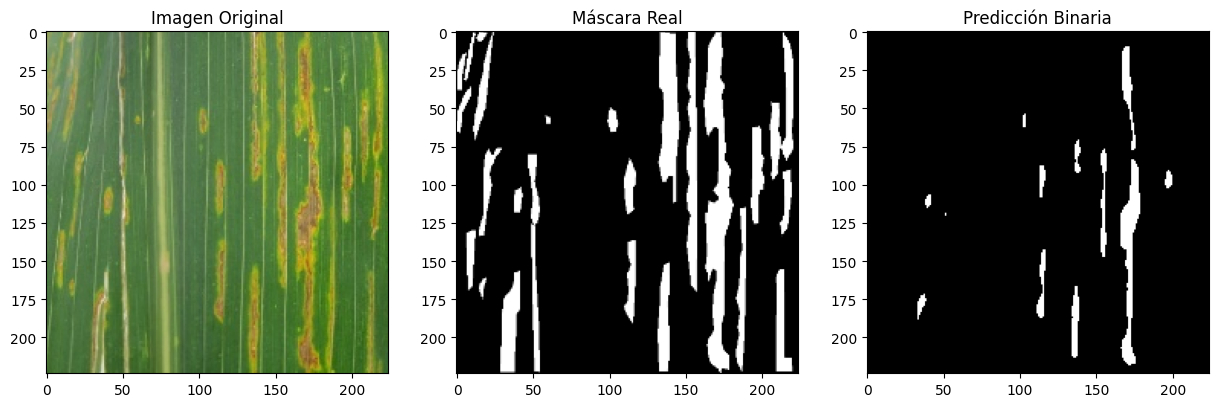

In [23]:
# Hacer predicciones sobre el conjunto de validación
predictions = model.predict(X_val)

# Convertir las predicciones a binarias (si es necesario)
binary_predictions = (predictions > 0.1).astype(np.uint8)

# Mostrar algunas predicciones junto con las máscaras reales para comparación
random_index = np.random.choice(len(X_val))

# Mostrar imagen original, máscara real y predicción binaria
plt.figure(figsize=(15, 5))

# Imagen original
plt.subplot(1, 3, 1)
plt.imshow(X_val[random_index])
plt.title('Imagen Original')

# Máscara real
plt.subplot(1, 3, 2)
plt.imshow(y_val[random_index], cmap='gray')
plt.title('Máscara Real')

# Predicción binaria
plt.subplot(1, 3, 3)
plt.imshow(binary_predictions[random_index], cmap='gray')
plt.title('Predicción Binaria')

plt.show()


In [ ]:
model.save('modelo_mask_v1.h5')

19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 329ms/step


Forma de la máscara predicha: (224, 224)
Predicción original: 2.49375831096188e-09, 0.1347537636756897
Máscara binaria: 0.0, 1.0


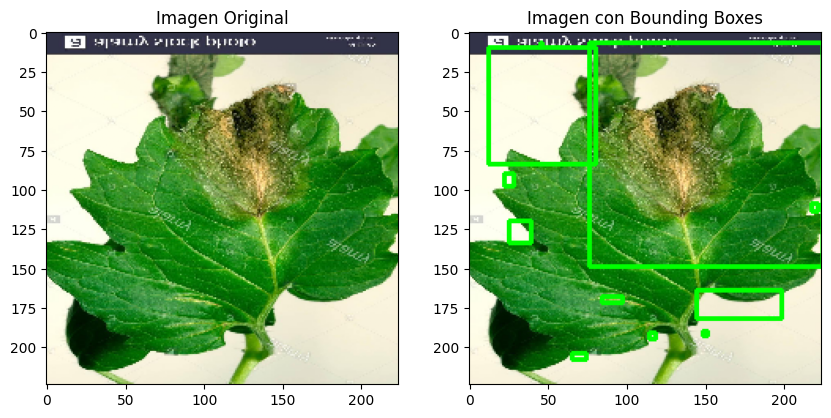

In [13]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# 1. Cargar el modelo .h5 previamente entrenado
model = tf.keras.models.load_model('modelo_mask_v1.h5')  # Reemplaza con la ruta de tu modelo

# 2. Hacer predicción sobre un conjunto de validación (X_val)
predictions = model.predict(X_val)

# 3. Convertir la predicción a binaria (máscara binaria)
def convert_to_binary_mask(prediction, threshold=None):
    """ Convierte la predicción a una máscara binaria (0 o 1). """
    if threshold is None:
        threshold = np.mean(prediction)  # Usar el valor medio como umbral
        
    print(f"Predicción original: {prediction.min()}, {prediction.max()}")  # Verificar los valores
    _, binary_mask = cv2.threshold(prediction, threshold, 1, cv2.THRESH_BINARY)
    print(f"Máscara binaria: {binary_mask.min()}, {binary_mask.max()}")  # Verificar los valores después de umbral
    return binary_mask

# 4. Encontrar los contornos y dibujar los bounding boxes
def draw_bounding_boxes(image, mask):
    """ Dibuja los bounding boxes sobre la imagen usando los contornos de la máscara. """
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Si no se encuentran contornos, imprime un mensaje
    if len(contours) == 0:
        print("No se encontraron contornos.")
    
    image_with_boxes = image.copy()
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(image_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Verde y grosor de 2

    return image_with_boxes

# 5. Visualización: Seleccionar una imagen aleatoria de validación y mostrar la predicción
random_index = np.random.choice(len(X_val))  # Selección aleatoria de un índice

# 6. Obtener la imagen y la máscara predicha (convertir a binaria)
image = X_val[random_index]  # Imagen original de validación
predicted_mask = predictions[random_index].squeeze()  # Máscara predicha (sin la dimensión extra)

# Verifica la forma de la máscara predicha
print(f"Forma de la máscara predicha: {predicted_mask.shape}")

# Convertir la predicción a binaria
binary_mask = convert_to_binary_mask(predicted_mask)  # Convertir la predicción a binaria

# 7. Dibujar bounding boxes sobre la imagen original
image_with_boxes = draw_bounding_boxes(image, binary_mask)

# 8. Mostrar la imagen original y la imagen con los bounding boxes
plt.figure(figsize=(10, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Imagen Original')

# Imagen con bounding boxes
plt.subplot(1, 2, 2)
plt.imshow(image_with_boxes)
plt.title('Imagen con Bounding Boxes')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step


Forma de la máscara predicha: (224, 224)


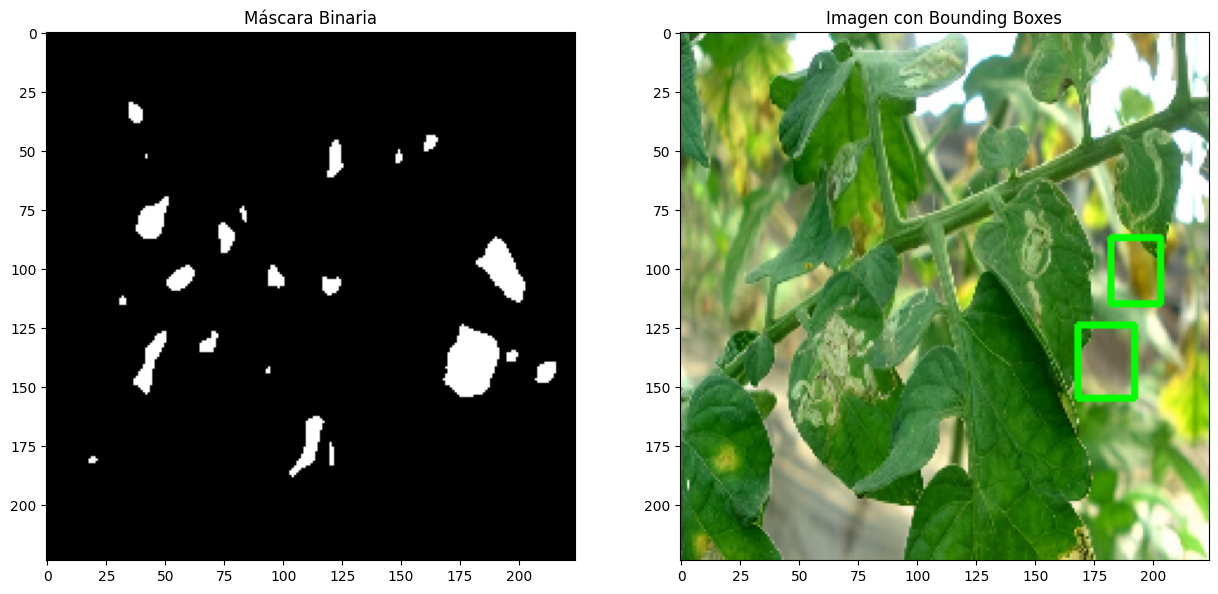

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# 1. Cargar el modelo .h5 previamente entrenado
model = tf.keras.models.load_model('modelo_mask_v1.h5')  # Reemplaza con la ruta de tu modelo

# 2. Cargar y preprocesar la imagen propia
image_path = '../Huevo/danios-de-minadores (1).jpg'  # Reemplaza con la ruta de tu imagen
image = load_img(image_path, target_size=(224, 224))  # Redimensiona la imagen al tamaño esperado por el modelo
image_array = img_to_array(image) / 255.0  # Normaliza la imagen a [0, 1]
image_array_resized = np.expand_dims(image_array, axis=0)  # Añadir la dimensión del lote (batch size)

# 3. Hacer predicción sobre la imagen cargada
predictions = model.predict(image_array_resized)

# 4. Convertir la predicción a binaria (máscara binaria)
def convert_to_binary_mask(prediction, threshold=0.06):
    """ Convierte la predicción a una máscara binaria (0 o 1). """
    _, binary_mask = cv2.threshold(prediction, threshold, 1, cv2.THRESH_BINARY)
    return binary_mask

# 5. Encontrar los contornos y dibujar los bounding boxes sobre las zonas de plaga
def draw_bounding_boxes(image, mask, min_contour_area=200):
    """ Dibuja los bounding boxes sobre la imagen usando los contornos de la máscara binaria. """
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filtrar los contornos pequeños (ruido)
    contours = [contour for contour in contours if cv2.contourArea(contour) > min_contour_area]

    # Si no se encuentran contornos, imprime un mensaje
    if len(contours) == 0:
        print("No se encontraron contornos significativos.")
    
    image_with_boxes = image.copy()
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(image_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Verde y grosor de 2

    return image_with_boxes

# 6. Obtener la máscara predicha (convertir a binaria)
predicted_mask = predictions[0].squeeze()  # Máscara predicha (sin la dimensión extra)

# Verifica la forma de la máscara predicha
print(f"Forma de la máscara predicha: {predicted_mask.shape}")

# Convertir la predicción a binaria
binary_mask = convert_to_binary_mask(predicted_mask)  # Convertir la predicción a binaria

# 7. Dibujar los bounding boxes sobre la imagen original (solo en las áreas de plaga)
image_with_boxes = draw_bounding_boxes(image_array, binary_mask)

# 8. Mostrar la imagen original con su máscara y luego la imagen con los bounding boxes
plt.figure(figsize=(15, 10))

# Imagen original con máscara binaria
plt.subplot(1, 2, 1)
plt.imshow(binary_mask, cmap='gray')  # Mostrar la máscara binaria
plt.title('Máscara Binaria')

# Imagen original con bounding boxes
plt.subplot(1, 2, 2)
plt.imshow(image_with_boxes)  # Mostrar la imagen con los bounding boxes
plt.title('Imagen con Bounding Boxes')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step


Forma de la máscara predicha: (224, 224)
Predicción original: 2.013205175899202e-07, 0.08840963244438171
Máscara binaria: 0.0, 1.0


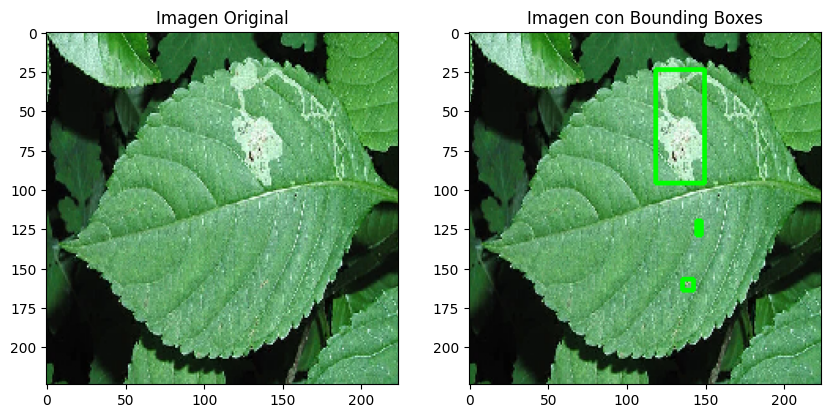

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# 1. Cargar el modelo .h5 previamente entrenado
model = tf.keras.models.load_model('modelo_mask_v1.h5')  # Reemplaza con la ruta de tu modelo

# 2. Cargar y preprocesar la imagen propia
image_path = '../Huevo/plaga.jpg'  # Reemplaza con la ruta de tu imagen
image = load_img(image_path, target_size=(224, 224))  # Redimensiona la imagen al tamaño esperado por el modelo
image = img_to_array(image) / 255.0  # Normaliza la imagen a [0, 1]
image = np.expand_dims(image, axis=0)  # Añadir la dimensión del lote (batch size)

# 3. Hacer predicción sobre la imagen cargada
predictions = model.predict(image)

# 4. Convertir la predicción a binaria (máscara binaria)
def convert_to_binary_mask(prediction, threshold=None):
    """ Convierte la predicción a una máscara binaria (0 o 1). """
    if threshold is None:
        threshold = np.mean(prediction)  # Usar el valor medio como umbral
        
    print(f"Predicción original: {prediction.min()}, {prediction.max()}")  # Verificar los valores
    _, binary_mask = cv2.threshold(prediction, threshold, 1, cv2.THRESH_BINARY)
    print(f"Máscara binaria: {binary_mask.min()}, {binary_mask.max()}")  # Verificar los valores después de umbral
    return binary_mask

# 5. Encontrar los contornos y dibujar los bounding boxes
def draw_bounding_boxes(image, mask):
    """ Dibuja los bounding boxes sobre la imagen usando los contornos de la máscara. """
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Si no se encuentran contornos, imprime un mensaje
    if len(contours) == 0:
        print("No se encontraron contornos.")
    
    image_with_boxes = image.copy()
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(image_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Verde y grosor de 2

    return image_with_boxes

# 6. Obtener la máscara predicha (convertir a binaria)
predicted_mask = predictions[0].squeeze()  # Máscara predicha (sin la dimensión extra)

# Verifica la forma de la máscara predicha
print(f"Forma de la máscara predicha: {predicted_mask.shape}")

# Convertir la predicción a binaria
binary_mask = convert_to_binary_mask(predicted_mask, threshold=0.035)  # Convertir la predicción a binaria

# 7. Dibujar bounding boxes sobre la imagen original
image_with_boxes = draw_bounding_boxes(image[0], binary_mask)  # Pasamos la imagen original sin la dimensión de lote

# 8. Mostrar la imagen original y la imagen con los bounding boxes
plt.figure(figsize=(10, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(image[0])  # Mostrar la imagen original
plt.title('Imagen Original')

# Imagen con bounding boxes
plt.subplot(1, 2, 2)
plt.imshow(image_with_boxes)  # Mostrar la imagen con los bounding boxes
plt.title('Imagen con Bounding Boxes')

plt.show()
